shape: (1100, 24)
alphas: [1.0, 11.0, 21.0, 31.0, 41.0, 51.0, 61.0, 71.0, 81.0, 91.0, 101.0]
chosen sample_id: [75, 43, 64, 8, 99]


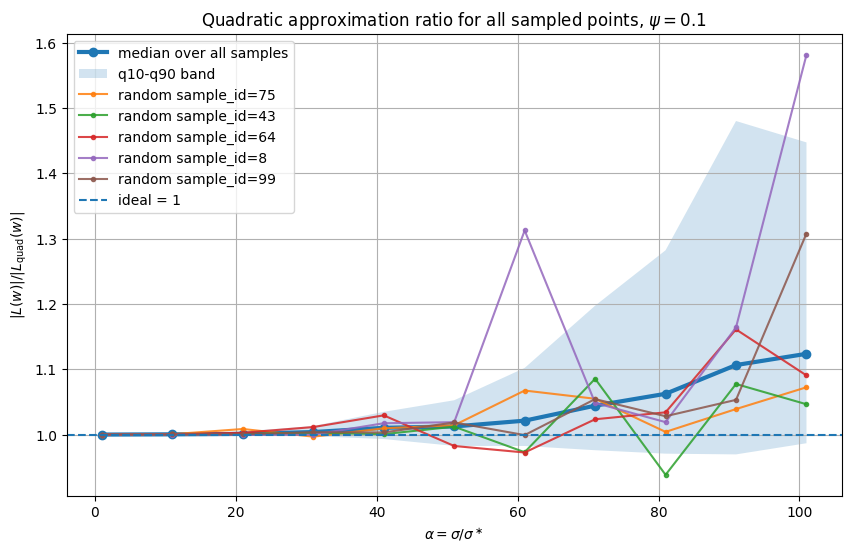

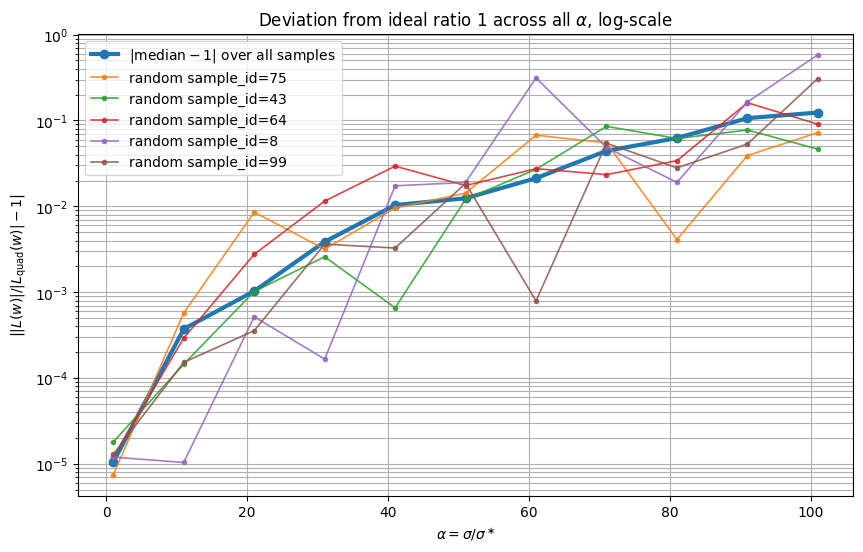

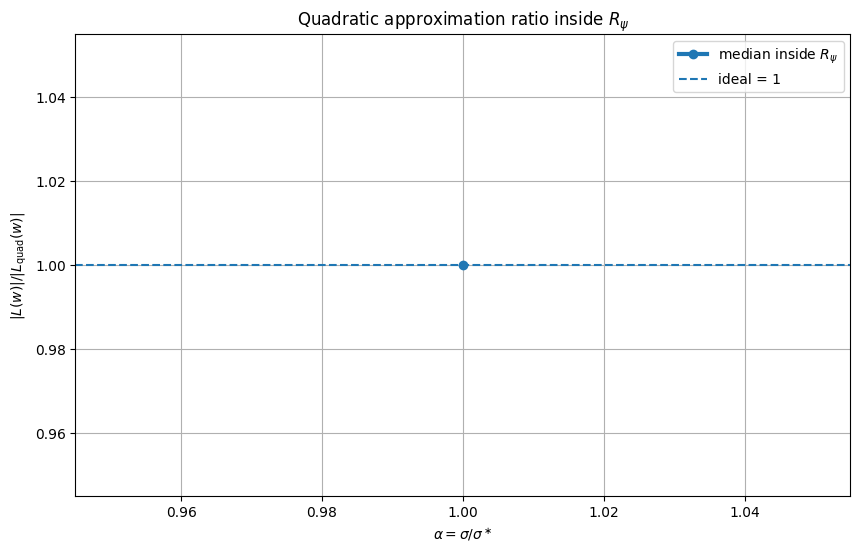

,alpha,median_ratio_inside
0,1.0,0.999989


,alpha,median_ratio
0,1.0,0.999989
1,11.0,1.000373
2,21.0,1.001032
3,31.0,1.003869
4,41.0,1.010353
5,51.0,1.012427
6,61.0,1.021289
7,71.0,1.044283
8,81.0,1.062447
9,91.0,1.106490


In [ ]:
# ============================================================
# ГРАФИКИ |L(w)| / |L_quad(w)| ДЛЯ ВСЕХ ALPHA
# без жесткого фильтра inside_ball, чтобы был весь диапазон x
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. ЗАГРУЗКА ДАННЫХ
# -----------------------------
if "new_mc_df" in globals():
    mc_plot_df = new_mc_df.copy()
else:
    csv_candidates = [
        "ll_calibration_backup/mc_samples_psi_0p1_alpha_1_101_step_10.csv",
        "/content/ll_calibration_backup/mc_samples_psi_0p1_alpha_1_101_step_10.csv",
        "mc_samples_psi_0p1_alpha_1_101_step_10.csv",
    ]

    mc_plot_df = None
    for path in csv_candidates:
        try:
            mc_plot_df = pd.read_csv(path)
            print("loaded:", path)
            break
        except Exception:
            pass

    if mc_plot_df is None:
        raise FileNotFoundError("Не найден csv с новыми сэмплами")

alpha_grid = list(range(1, 102, 10))
mc_plot_df = mc_plot_df[mc_plot_df["alpha"].isin(alpha_grid)].copy()

if "psi" in mc_plot_df.columns:
    mc_plot_df = mc_plot_df[np.isclose(mc_plot_df["psi"], 0.1)].copy()

mc_plot_df = mc_plot_df.sort_values(["alpha", "sample_id"]).reset_index(drop=True)

print("shape:", mc_plot_df.shape)
print("alphas:", sorted(mc_plot_df["alpha"].unique().tolist()))

if "quad_accuracy_ratio" not in mc_plot_df.columns:
    raise ValueError("В данных нет колонки quad_accuracy_ratio")


# -----------------------------
# 2. МЕДИАНА ПО ВСЕМ ТОЧКАМ
# -----------------------------
median_all = (
    mc_plot_df
    .groupby("alpha", as_index=False)["quad_accuracy_ratio"]
    .median()
    .rename(columns={"quad_accuracy_ratio": "median_ratio"})
    .sort_values("alpha")
)

# при желании ещё q10/q90 для коридора
qband_all = (
    mc_plot_df
    .groupby("alpha")["quad_accuracy_ratio"]
    .quantile([0.1, 0.9])
    .unstack()
    .reset_index()
    .rename(columns={0.1: "q10", 0.9: "q90"})
    .sort_values("alpha")
)


# -----------------------------
# 3. НЕСКОЛЬКО СЛУЧАЙНЫХ ТРАЕКТОРИЙ
# -----------------------------
# В твоих данных sample_id одинаково пробегает все alpha,
# так что можно взять одни и те же sample_id и показать их по всей оси x.
rng = np.random.default_rng(42)
N_RANDOM_CURVES = 5

counts_per_sample = mc_plot_df.groupby("sample_id")["alpha"].nunique()
full_sample_ids = counts_per_sample[counts_per_sample == len(alpha_grid)].index.tolist()

if len(full_sample_ids) == 0:
    raise ValueError("Нет sample_id с полным покрытием по всем alpha")

chosen_ids = rng.choice(
    full_sample_ids,
    size=min(N_RANDOM_CURVES, len(full_sample_ids)),
    replace=False
).tolist()

print("chosen sample_id:", chosen_ids)


# -----------------------------
# 4. ОСНОВНОЙ ГРАФИК: median + random trajectories
# -----------------------------
plt.figure(figsize=(10, 6))

# медиана по всем сэмплам
plt.plot(
    median_all["alpha"],
    median_all["median_ratio"],
    marker="o",
    linewidth=3,
    label="median over all samples"
)

# коридор q10-q90
plt.fill_between(
    qband_all["alpha"],
    qband_all["q10"],
    qband_all["q90"],
    alpha=0.2,
    label="q10-q90 band"
)

# несколько случайных траекторий
for sid in chosen_ids:
    g = mc_plot_df[mc_plot_df["sample_id"] == sid].sort_values("alpha")
    plt.plot(
        g["alpha"],
        g["quad_accuracy_ratio"],
        marker=".",
        linewidth=1.5,
        alpha=0.85,
        label=f"random sample_id={sid}"
    )

plt.axhline(1.0, linestyle="--", linewidth=1.5, label="ideal = 1")
plt.xlabel(r"$\alpha = \sigma / \sigma^\ast$")
plt.ylabel(r"$|L(w)| / |L_{\mathrm{quad}}(w)|$")
plt.title(r"Quadratic approximation ratio for all sampled points, $\psi=0.1$")
plt.grid(True)
plt.legend()
plt.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.show()


# -----------------------------
# 5. БОЛЕЕ ЧУВСТВИТЕЛЬНЫЙ ГРАФИК:
# отклонение от 1 в лог-масштабе
# -----------------------------
plt.figure(figsize=(10, 6))

median_dev = np.abs(median_all["median_ratio"] - 1.0) + 1e-12
plt.plot(
    median_all["alpha"],
    median_dev,
    marker="o",
    linewidth=3,
    label=r"$|\mathrm{median} - 1|$ over all samples"
)

for sid in chosen_ids:
    g = mc_plot_df[mc_plot_df["sample_id"] == sid].sort_values("alpha")
    dev = np.abs(g["quad_accuracy_ratio"].values - 1.0) + 1e-12
    plt.plot(
        g["alpha"],
        dev,
        marker=".",
        linewidth=1.2,
        alpha=0.85,
        label=f"random sample_id={sid}"
    )

plt.yscale("log")
plt.xlabel(r"$\alpha = \sigma / \sigma^\ast$")
plt.ylabel(r"$\left||L(w)|/|L_{\mathrm{quad}}(w)| - 1\right|$")
plt.title(r"Deviation from ideal ratio 1 across all $\alpha$, log-scale")
plt.grid(True, which="both")
plt.legend()
plt.show()


# -----------------------------
# 6. ОПЦИОНАЛЬНО:
# тот же график только inside R_psi, но без ожидания,
# что будут точки на всех alpha
# -----------------------------
inside_df = mc_plot_df[mc_plot_df["inside_ball"] == 1].copy()

if len(inside_df) > 0:
    median_inside = (
        inside_df
        .groupby("alpha", as_index=False)["quad_accuracy_ratio"]
        .median()
        .rename(columns={"quad_accuracy_ratio": "median_ratio_inside"})
        .sort_values("alpha")
    )

    plt.figure(figsize=(10, 6))
    plt.plot(
        median_inside["alpha"],
        median_inside["median_ratio_inside"],
        marker="o",
        linewidth=3,
        label="median inside $R_\\psi$"
    )
    plt.axhline(1.0, linestyle="--", linewidth=1.5, label="ideal = 1")
    plt.xlabel(r"$\alpha = \sigma / \sigma^\ast$")
    plt.ylabel(r"$|L(w)| / |L_{\mathrm{quad}}(w)|$")
    plt.title(r"Quadratic approximation ratio inside $R_\psi$")
    plt.grid(True)
    plt.legend()
    plt.ticklabel_format(axis="y", style="plain", useOffset=False)
    plt.show()

    display(median_inside)
else:
    print("Нет точек inside R_psi")


# -----------------------------
# 7. ТАБЛИЦА ДЛЯ КОНТРОЛЯ
# -----------------------------
display(median_all)